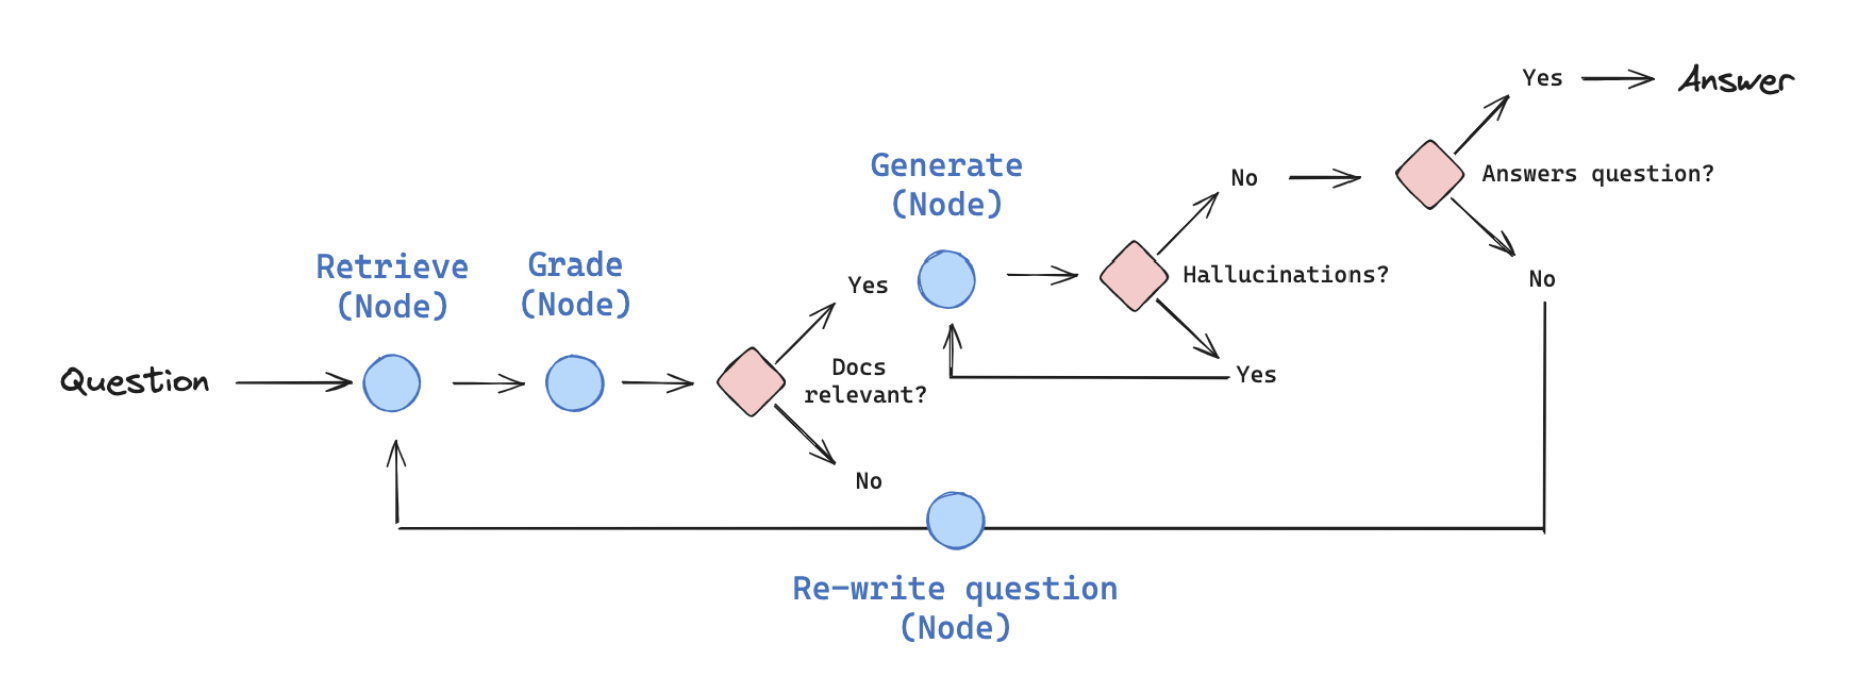

1. 앞부분은 지금까지 했었던 내용
2. rewrite 가 아니라, 여기서는 relevant 하지 않으면 NO 
3. 이번에는 더 나아가서 생성한 답변을 "검증" 하고 <br>
    3-1. 생성한 답변이 문서를 기반으로 했는지 검증을 해서 - [YES] - 답변 다시 생성 <br>
    3-2. 생성한 답변이 문서를 기반으로 했다면 -[NO] - 생성한 답변이 질문과 관련이 있는지 검증 - [NO] - rewrite 해서 retrieve부터 전체적인 싸이클 다시 시작

### 기존 노드 활용

In [1]:
# 생성된 벡터스토어에 접근 -> 클래스만 바로 써야 함
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

In [2]:
# state 생성

from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str   # 사용자의 질문
    context:List[Document]  # 답변을 만들때 참고할 문서들 - langchain의 다큐먼트들을 리스트 형태로 반환 
    answer: str


graph_builder = StateGraph(AgentState)  # 빌더 생성

In [3]:

# 노드 생성

# retrieve
def retrieve(state:AgentState):
    query = state['query']  # 사용자의 질문을 꺼내온다
    docs = retriever.invoke(query)  # 사용자의 질문을 기반으로 문서 검색
    return {'context' : docs}    # 검색된 결과를  state의 context에 넣어서 반환


In [4]:
# llm과 prompt 분리 
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o-mini')  # 가격을 위해서 mini로 대체

In [5]:
from langchain_classic import hub

generate_prompt = hub.pull("rlm/rag-prompt") 

generate_llm = ChatOpenAI(model='gpt-4o-mini', max_completion_tokens=100)  # 4. 할루시네이션 프롬프트 수정 : max_token 제한
# generate
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm
    response = rag_chain.invoke({'question': query, 'context':context})
    return {'answer' : response.content}   # 2. 할루시네이션 프롬프트 수정 - answer 포맷 수정 [AIMessage이기 때문에 .content로 수정해준다]

In [6]:
# 수정
# 여기서는 rewrite가 아니라, 바로 END 를 해줘야 한다 (위 그림 참고)
# relevant, irrelevant 로 나눠서 처리 

from langchain_classic import hub
from typing import Literal
doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']: # return type이 conditional edge에서 활용하기 위해서 Literal로 되어있음 (state를 반환하는게 아니라, "노드"를 반환해야 함)
    context = state['context']
    query = state['query']
    print(f'context == {context}') 
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents':context})  # 인자를 공식문서에 맞게 바꿔야함
    print(f'doc relevance response == {response}') 
    # return {'relevance_score' : response}
    # state를 반환하면 안됨, conditional edge에서 활용하기 위해서 relevance_score만 반환
    if response['Score'] == 1:
        # return 'generate'
        return 'relevant' 
    
    # return 'rewrite'
    # return 'END'  # 에러 : 노드가 아니기 때문에, Literal로 넘겨도 작동 안함 (엣지 둥록할때 처리)
    return 'irrelevant'  # generate로 가도 relevance가 낮은 문서들이 섞여있을 수 있기 때문에, rewrite로 가는 경우에도 relevance가 낮은 문서들이 있을 수 있음. 따라서, relevance가 낮은 문서들이 섞여있을 때, relevance가 낮은 문서들을 제거하는 rewrite 과정을 거치도록 함. (conditional edge에서 처리)


In [7]:
# 위 문제를 해결하기 위한 템플릿 직접 작성

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


dictionary = ['사람과 관련된 표현 -> 거주자']  # 참고 : 문서 답변이 잘 나오지 않아서, txt파일을 강의자료에 있는걸로 대체하였다 -> 그래서 사전도 강의랑 똑같이 진행
              
rewrite_template = PromptTemplate.from_template(f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
    사전 : {dictionary}
    질문 : {{query}}
    """
)

def rewrite(state: AgentState):
    query = state['query']

    # response (output)을 string만 나오게끔 변경 (state의 query 타입이 str이므로, str을 받을 수 있게 타입을 변경해주자)
    rewrite_chain = rewrite_template | llm | StrOutputParser()  # output이 string이 되도록 체인에 파서 연결
    response = rewrite_chain.invoke({'query': query})  # [response] : 원래 AIMessage타입이었는데, StrOutputParser() 때문에 string 타입으로 바뀜
    
    return {'query': response}

### 새로운 노드 작성

In [8]:
# # 노드 작성
# from langchain_classic import hub

# # 할루시네이션 검증 프롬프트
# hallucination_prompt = hub.pull("langchain-ai/rag-answer-hallucination")


# def check_hallucianations(state: AgentState):
#     answer = state['answer']  # 사용자의 답변을 봐야 함
#     context = state['context']

#     print(f'context == {context}') 
#     hallucination_chain = hallucination_prompt | llm
#     response = hallucination_chain.invoke({'student_answer':answer, 'documents':context})  # 공식문서 상, key값을 변경해야 함
#     print(f'hallucination response == {response}') 

#     if response['Score'] == 1:
#         return 'generate'
    
#     return 'end'  # 할루시네이션 O - 끝난 것





In [9]:
# 1. hallucination 

# 1. 할루시네이션 프롬프트 수정 - 답변이 잘 나왔는데도 할루시네이션이라고 나와서 프롬프트 수정
# 디테일하게 수정 - [페르소나를 부여하고] & [태스트 지정] & [팩트에 대한 디테일한 설명; 소득세법에 근거한] 
    # 이렇게 했는데도, hallucination response 에서 "factual inaccuracy" 라는 내용으로 나올 수 있다. -> 더 섬세하게 프롬프트를 수정해보도록 함
    # 프롬프트에 Check wheter the student's answer is hallucinated or not 이 부분을 구체적으로 작성
        # [할루시네이션이란, 무엇인지] 에 대한 정보를 추가함

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser 

hallucination_prompt = PromptTemplate.from_template("""
    You are a teacher tasked with evaluating whether a student's answer is based on documents or not,
    Given documents, which are excerpts from income tax law, and a student's answer;                              
    If the student's answer is based on documents, respond with "not hallucinated",
    If the student's answer is not based on documents, respond with "hallucinated".
                               
    documents : {documents}
    student_answer : {student_answer}
    """) 

hallucination_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)  # 4. 할루시네이션 프롬프트 수정 (노션 참고)

def check_hallucianations(state: AgentState)  -> Literal['hallucinated', 'not hallucinated']:
    answer = state['answer']  # 사용자의 답변을 봐야 함 
    context = state['context']  
    context = [doc.page_content for doc in context]   # 3. 할루시네이션 프롬프트 수정 (추가) : List[Doc] ⇒ string만 넣도록 수정

    print(f'context == {context}') 
    hallucination_chain = hallucination_prompt | hallucination_llm | StrOutputParser()
    response = hallucination_chain.invoke({'student_answer':answer, 'documents':context})  # 공식문서 상, key값을 변경해야 함
    print(f'hallucination response == {response}') 
    

    return response  # 할루시네이션 O - 끝난 것


#### rag-answer-helpfulness 사용자의 질문과 답변의 관련성

In [10]:
from langchain_classic import hub


helpfulness_prompt = hub.pull("langchain-ai/rag-answer-helpfulness")

def check_helpfulness_grader(state:AgentState):
    query = state['query']
    answer = state ['answer']
    helpfulness_chain = helpfulness_prompt | llm
    response = helpfulness_chain.invoke({'question': query, 'student_answer':answer})

    print(f'helpfulness response == {response}') 

    # return response가 아니라 score를 기반으로 나눠야 한다. 
    if response['Score'] == 1:
        return 'helpful'
    
    return 'unhelpful'


def check_helpfulness(state:AgentState):
    return state

##### 생성한 노드검증

In [11]:
# 새로운 노드 검증
# 참고 : 문서 자체도 잘 안나와서 txt파일 대체
query = '연봉 5천만원인 거주자의 소득세는 얼마인가요?'
context = retriever.invoke(query)

for document in context:
    print(document.page_content)

generate_state = {'query': query, 'context':context}  
answer = generate(generate_state)    # 답변은 generate에서 받아온다
print(f'answer == {answer}') 


# hallucination 검중 - 할루시네이션 프롬프트 문제로, 여러 군데의 디버깅 과정을 거침
# hallucination_state = {'answer': answer, 'context':context}
# check_hallucianations(hallucination_state) 


# helpfulness 검중 - score 1 (helpful) 로 잘 나오는 것 확인함 
helpfulness_state = {'query' : query, 'answer' : answer}
check_helpfulness_grader(helpfulness_state)


② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>
  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. 
[개정 2014. 1. 1.]
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제2절 세액의 계산 <개정 2009. 12. 31.>
제1관 세율 <개정 2009. 12. 31.>
제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>
종합소득
┌───────────────┐
│ 과세표준의 6개 구간 │
├───────────────┤
│ 1,400만원 이하        │ 84만원  │
│ 1,400만원 초과        │ 84만원 + (5,000만원을 초과하는 금액의 24%)  │
│ 8,800만원 이하        │ 

'helpful'

- 'end' 가 나오는 이유? (할루시네이션이 나오는 이유)
---
- 문서는 잘 들어감, answer도 624만원이라고 잘 나옴
- hallucination_response 가 0으로 나오는 이유는
     - hallucination_prompt가 잘못 동작하고 있거나
     - answer가 너무 길어서
- 두 가지 정도 방안을 기대해볼 수 있다
     - 1. generate의 체인을 수정해서 답변의 길이를 짧게 하는 방법
     - 2. hallucination 프롬프트를 수정하는 방법 v

### 그래프 빌드

In [12]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

# 주석처리 - 일단 모두 추가해 두고, 그래프 빌드를 한 다음, 동떨어진 노드들이 있다면 그냥 제거해주자
# 3.rewrite.ipynb 파일에서 이 부분 다시 참고
# graph_builder.add_node('check_doc_relevance', check_doc_relevance)
# graph_builder.add_node('check_hallucianations', check_hallucianations) # 오타 주의

graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('check_helpfulness', check_helpfulness_grader)
# 일단 생성한 모든 노드를 추가하자 

In [13]:
 # 엣지 추가
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')

# retriever가 들어오면, retrieve 는 check_doc_relevance를 수행 -> relevant / irrelevant에 따라서 노드 연결
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant' : 'generate',
        'irrelevant' : END
    }
)

# hallucination이면 -> "답변을 다시 생성" 해야 하므로, rewrite가 아니라, generate를 해줘야 한다
graph_builder.add_conditional_edges(
    'generate',
    check_hallucianations,
    {
        'not hallucinated' : 'check_helpfulness',
        'hallucinated' : 'generate'
    }
)

# check_helpfulness 를 본다 -> helpful 하면 끝, 아니면 rewrite 해서 다시 생성
graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful' : END,
        'unhelpful' : 'rewrite'
    }
)

graph_builder.add_edge('rewrite', 'retrieve')


In [14]:
graph = graph_builder.compile()

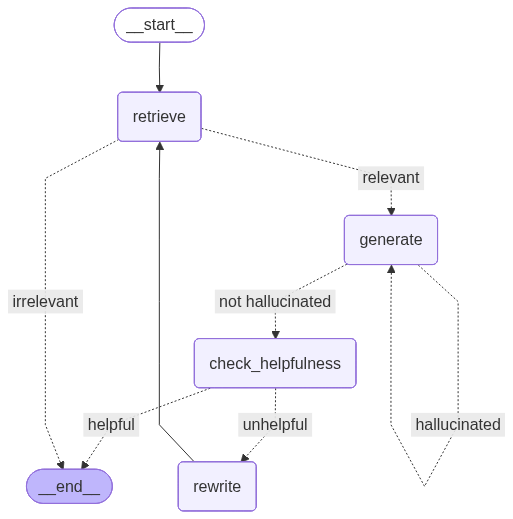

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  # 시퀀스 다이어그램으로 노드 간의 흐름을 볼 수 있다 
# 시퀀스는 일일히 노드와 엣지를 추가하는 과정을 거치지 않아도 된다

#### 그래프 호출

In [16]:
# initial_state = {'query' : '배가 고파요'} # 문서와 관련이 없기 때문에, 끝나버린다
initial_state = {'query' : '연봉 5천만원 거주자가 납부해야 하는 소득세는 얼마인가요'} 
graph.invoke(initial_state)


context == [Document(id='5db2ab82-7abf-4612-8e35-e70504f4e855', metadata={'source': './docs/income_tax.txt'}, page_content='5년 이하: 30만원 → 납입연수\n5년 초과 10년 이하: 150만원 + 50만원 × (납입연수 - 5년)\n10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. \n<대통령 2014. 12. 23.>\n<전문개정 2009. 12. 31.>\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. \n<개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액\n  가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액\n  나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액'), Document(id='88ace334-edae-4d17-b6ba-850b2c9b99a5', metadata={'source': './docs/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 

InvalidUpdateError: Expected dict, got helpful
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE